# Create annual SPEI12 data

This notebook reads in monthly SPEI12 indices and uses them to create annual drought indices to use as a Hazard object to model annual crop losses.

Since the crops we're modelling have different growing seasons, we use a different set of months to create crop-specific drought indices.



In [33]:
# ============================================================
# READ MONTHLY SPEI GEOTIFF
# ============================================================
# For each year:
#   select crop growing months
#   take most negative SPEI during growing season
# ============================================================

import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from rasterio.transform import xy
from scipy import sparse
from datetime import datetime

from climada.hazard import Hazard, Centroids
from climada.util.dates_times import str_to_date

SPEI12_DIR = "../../data/hazard/monthly"
SPEI12_MONTHLY_FILES = {
    "present": "ElSalvador_SPEI12_MONTHLY_1971_to_2025.tif",
    "future": "ElSalvador_SPEI12_MONTHLY_2026_to_2050.tif"
}

GROWING_SEASONS = {
    "maize": [6, 7, 8, 9, 10, 11],   # Main maize growing season
    "beans": [5, 6, 7, 8],           # Main beans growing seasons
    "sorghum": [7, 8, 9, 10, 11, 12] # If you extend this season to January, the code below will need to be modified
}

HAZ_TYPE = "DR"


# ============================================================
# HELPER FUNCTION: Extract dates from band names in .tif file
# ============================================================

def parse_band_date(desc):
    """
    Parse date from tif file's band descriptions
    Example: SPEI12_1971_12
    """

    parts = desc.split("_")
    year = int(parts[-2])
    month = int(parts[-1])
    return datetime(year, month, 15)


# ============================================================
# METHOD TO PROCESS CREATE NEW HAZARD
# ============================================================

def read_hazard_yearly_crop_season(path, crop, growing_months):
    """
    Read monthly SPEI GeoTIFF and aggregate it to yearly crop-season events.
    """

    print(f"Reading drought data from {path}")

    with rasterio.open(path) as src:

        data = src.read().astype(float)
        descriptions = src.descriptions
        transform = src.transform
        nodata = src.nodata

        n_bands, n_rows, n_cols = data.shape

        if nodata is not None:
            data[data == nodata] = np.nan

        # --------------------------------------------------------
        # Parse monthly dates
        # --------------------------------------------------------

        band_dates = [parse_band_date(desc) for desc in descriptions]
        band_dates = pd.to_datetime(band_dates)

        print("Crop: ", crop)
        print("Original monthly bands: ", n_bands)
        print("First monthly date: ", band_dates[0])
        print("Last monthly date: ", band_dates[-1])
        print("Growing months: ", growing_months)

        # --------------------------------------------------------
        # Create raster centroids
        # --------------------------------------------------------

        lons = []
        lats = []

        for row in range(n_rows):
            for col in range(n_cols):
                lon, lat = xy(
                    transform,
                    row,
                    col,
                    offset="center"
                )
                lons.append(lon)
                lats.append(lat)

        lons = np.array(lons)
        lats = np.array(lats)

        # --------------------------------------------------------
        # Aggregate monthly bands to one event per year
        # --------------------------------------------------------

        yearly_arrays = []
        event_names = []
        event_dates = []

        years = sorted(np.unique(band_dates.year))

        for year in years:

            if year == 1971:       # Year is incomplete
                continue

            season_mask = (
                (band_dates.year == year) &
                (band_dates.month.isin(growing_months))
            )

            if season_mask.sum() < len(growing_months):
                raise ValueError(f"No data found for year {year}")

            season_data = data[season_mask, :, :]

            # Most severe drought = most negative SPEI
            yearly_spei = np.nanmin(
                season_data,
                axis=0
            )

            yearly_arrays.append(yearly_spei)

            event_names.append(
                f"{crop}_SPEI12_growing_season_{year}"
            )

            event_dates.append(
                str_to_date(f"{year}-{growing_months[0]}-01")
            )

        n_events = len(yearly_arrays)
        yearly_stack = np.stack(
            yearly_arrays,
            axis=0
        )

        intensity = yearly_stack.reshape(
            n_events,
            n_rows * n_cols
        )

        # Identify locations where there are missing values
        # (this happens over mostly-ocean pixels in some future years, for an unknown reason)
        valid_pixels = ~np.any(
            np.isnan(intensity),
            axis=0
        )

        # Discard anywhere with missing values
        intensity = intensity[:, valid_pixels]
        assert ~np.any(np.isnan(intensity))

        # intensity = np.nan_to_num(
        #     intensity,
        #     nan=9999.0
        # )

        lons_valid = lons[valid_pixels]
        lats_valid = lats[valid_pixels]

    # ------------------------------------------------------------
    # Build CLIMADA Hazard
    # ------------------------------------------------------------

    # Create 'empty' hazard
    haz = Hazard(haz_type=HAZ_TYPE)

    # Define Centroids
    haz.centroids = Centroids.from_lat_lon(
        lats_valid,
        lons_valid
    )

    haz.intensity = sparse.csr_matrix(
        intensity
    )

    haz.fraction = sparse.csr_matrix(
        np.ones_like(intensity)
    )

    haz.event_id = np.arange(1, n_events + 1)
    haz.event_name = event_names
    haz.date = np.array(event_dates)

    # frequency is one event per year
    haz.frequency = np.ones(n_events) / n_events

    haz.units = "SPEI"   # "" is also valid, since the index is dimensionless. As long as it matches what's defined in the impact function

    haz.check()

    return haz



Scenario: present

Crop: maize
Reading drought data from ../../data/hazard/monthly/ElSalvador_SPEI12_MONTHLY_1971_to_2025.tif
Crop:  maize
Original monthly bands:  649
First monthly date:  1971-12-15 00:00:00
Last monthly date:  2025-12-15 00:00:00
Growing months:  [6, 7, 8, 9, 10, 11]
Hazard shape: (54, 15)
First 5 events: ['maize_SPEI12_growing_season_1972', 'maize_SPEI12_growing_season_1973', 'maize_SPEI12_growing_season_1974', 'maize_SPEI12_growing_season_1975', 'maize_SPEI12_growing_season_1976']
Last 5 events: ['maize_SPEI12_growing_season_2021', 'maize_SPEI12_growing_season_2022', 'maize_SPEI12_growing_season_2023', 'maize_SPEI12_growing_season_2024', 'maize_SPEI12_growing_season_2025']
Intensity min: -5.831377029418945
Intensity max: 1.5719375610351562
2026-05-27 19:07:54,375 - climada.hazard.io - INFO - Writing ../../data/hazard/annual/ElSalvador_SPEI12_present_maize.hdf5
2026-05-27 19:07:54,407 - climada.hazard.centroids.centr - INFO - Writing ../../data/hazard/annual/ElSalv

/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_35385/799208153.py:187: DeprecatedWarning: from_lat_lon is deprecated. This method will be removed in a future version. Simply use the constructor instead.
  haz.centroids = Centroids.from_lat_lon(



Crop: beans
Reading drought data from ../../data/hazard/monthly/ElSalvador_SPEI12_MONTHLY_1971_to_2025.tif
Crop:  beans
Original monthly bands:  649
First monthly date:  1971-12-15 00:00:00
Last monthly date:  2025-12-15 00:00:00
Growing months:  [5, 6, 7, 8]
Hazard shape: (54, 15)
First 5 events: ['beans_SPEI12_growing_season_1972', 'beans_SPEI12_growing_season_1973', 'beans_SPEI12_growing_season_1974', 'beans_SPEI12_growing_season_1975', 'beans_SPEI12_growing_season_1976']
Last 5 events: ['beans_SPEI12_growing_season_2021', 'beans_SPEI12_growing_season_2022', 'beans_SPEI12_growing_season_2023', 'beans_SPEI12_growing_season_2024', 'beans_SPEI12_growing_season_2025']
Intensity min: -5.831377029418945
Intensity max: 2.3500027656555176
2026-05-27 19:07:56,703 - climada.hazard.io - INFO - Writing ../../data/hazard/annual/ElSalvador_SPEI12_present_beans.hdf5
2026-05-27 19:07:56,787 - climada.hazard.centroids.centr - INFO - Writing ../../data/hazard/annual/ElSalvador_SPEI12_present_beans.h

/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_35385/799208153.py:187: DeprecatedWarning: from_lat_lon is deprecated. This method will be removed in a future version. Simply use the constructor instead.
  haz.centroids = Centroids.from_lat_lon(



Crop: sorghum
Reading drought data from ../../data/hazard/monthly/ElSalvador_SPEI12_MONTHLY_1971_to_2025.tif
Crop:  sorghum
Original monthly bands:  649
First monthly date:  1971-12-15 00:00:00
Last monthly date:  2025-12-15 00:00:00
Growing months:  [7, 8, 9, 10, 11, 12]
Hazard shape: (54, 15)
First 5 events: ['sorghum_SPEI12_growing_season_1972', 'sorghum_SPEI12_growing_season_1973', 'sorghum_SPEI12_growing_season_1974', 'sorghum_SPEI12_growing_season_1975', 'sorghum_SPEI12_growing_season_1976']
Last 5 events: ['sorghum_SPEI12_growing_season_2021', 'sorghum_SPEI12_growing_season_2022', 'sorghum_SPEI12_growing_season_2023', 'sorghum_SPEI12_growing_season_2024', 'sorghum_SPEI12_growing_season_2025']
Intensity min: -4.955569744110107
Intensity max: 1.5719375610351562
2026-05-27 19:07:58,530 - climada.hazard.io - INFO - Writing ../../data/hazard/annual/ElSalvador_SPEI12_present_sorghum.hdf5
2026-05-27 19:07:58,578 - climada.hazard.centroids.centr - INFO - Writing ../../data/hazard/annua

...

/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_35385/799208153.py:187: DeprecatedWarning: from_lat_lon is deprecated. This method will be removed in a future version. Simply use the constructor instead.
  haz.centroids = Centroids.from_lat_lon(



Crop: beans
Reading drought data from ../../data/hazard/monthly/ElSalvador_SPEI12_MONTHLY_2026_to_2050.tif
Crop:  beans
Original monthly bands:  300
First monthly date:  2026-01-15 00:00:00
Last monthly date:  2050-12-15 00:00:00
Growing months:  [5, 6, 7, 8]
Hazard shape: (25, 14)
First 5 events: ['beans_SPEI12_growing_season_2026', 'beans_SPEI12_growing_season_2027', 'beans_SPEI12_growing_season_2028', 'beans_SPEI12_growing_season_2029', 'beans_SPEI12_growing_season_2030']
Last 5 events: ['beans_SPEI12_growing_season_2046', 'beans_SPEI12_growing_season_2047', 'beans_SPEI12_growing_season_2048', 'beans_SPEI12_growing_season_2049', 'beans_SPEI12_growing_season_2050']
Intensity min: -6.365318298339844
Intensity max: 1.6931108236312866
2026-05-27 19:08:00,954 - climada.hazard.io - INFO - Writing ../../data/hazard/annual/ElSalvador_SPEI12_future_beans.hdf5
2026-05-27 19:08:01,008 - climada.hazard.centroids.centr - INFO - Writing ../../data/hazard/annual/ElSalvador_SPEI12_future_beans.hdf

/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_35385/799208153.py:134: RuntimeWarning: All-NaN slice encountered
  yearly_spei = np.nanmin(
/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_35385/799208153.py:187: DeprecatedWarning: from_lat_lon is deprecated. This method will be removed in a future version. Simply use the constructor instead.
  haz.centroids = Centroids.from_lat_lon(



Crop: sorghum
Reading drought data from ../../data/hazard/monthly/ElSalvador_SPEI12_MONTHLY_2026_to_2050.tif
Crop:  sorghum
Original monthly bands:  300
First monthly date:  2026-01-15 00:00:00
Last monthly date:  2050-12-15 00:00:00
Growing months:  [7, 8, 9, 10, 11, 12]
Hazard shape: (25, 15)
First 5 events: ['sorghum_SPEI12_growing_season_2026', 'sorghum_SPEI12_growing_season_2027', 'sorghum_SPEI12_growing_season_2028', 'sorghum_SPEI12_growing_season_2029', 'sorghum_SPEI12_growing_season_2030']
Last 5 events: ['sorghum_SPEI12_growing_season_2046', 'sorghum_SPEI12_growing_season_2047', 'sorghum_SPEI12_growing_season_2048', 'sorghum_SPEI12_growing_season_2049', 'sorghum_SPEI12_growing_season_2050']
Intensity min: -6.365318298339844
Intensity max: 0.03274570032954216
2026-05-27 19:08:02,167 - climada.hazard.io - INFO - Writing ../../data/hazard/annual/ElSalvador_SPEI12_future_sorghum.hdf5
2026-05-27 19:08:02,201 - climada.hazard.centroids.centr - INFO - Writing ../../data/hazard/annua

/var/folders/cs/l_5t6dbs03l7xx658mdw_t6w0000gn/T/ipykernel_35385/799208153.py:187: DeprecatedWarning: from_lat_lon is deprecated. This method will be removed in a future version. Simply use the constructor instead.
  haz.centroids = Centroids.from_lat_lon(


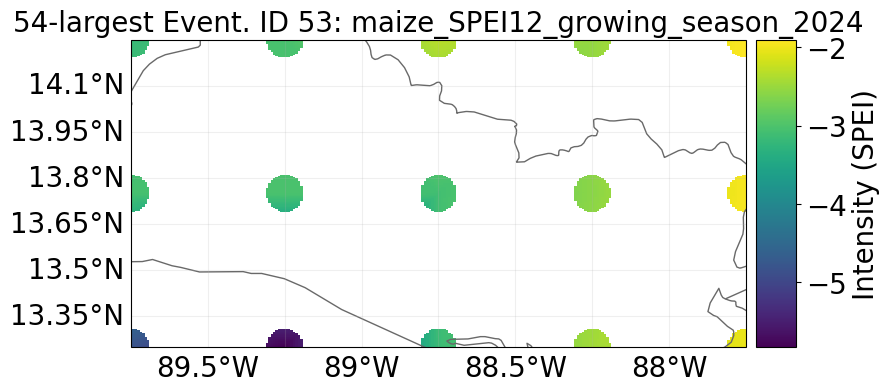

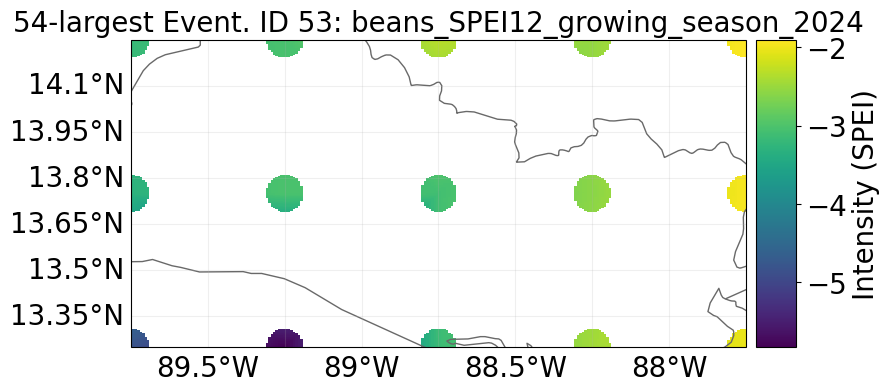

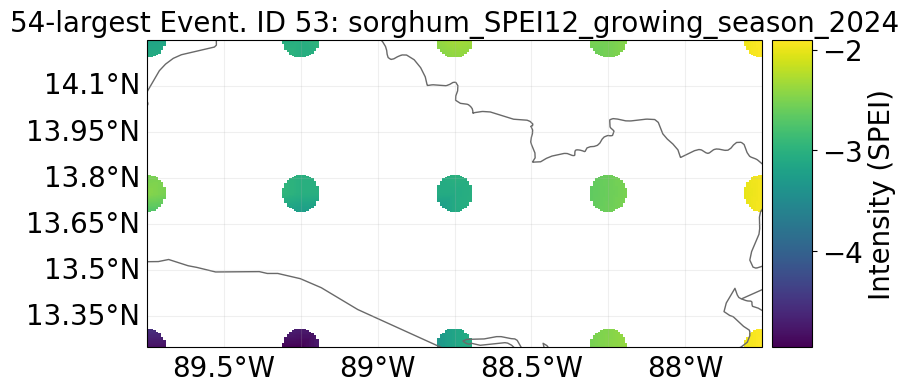

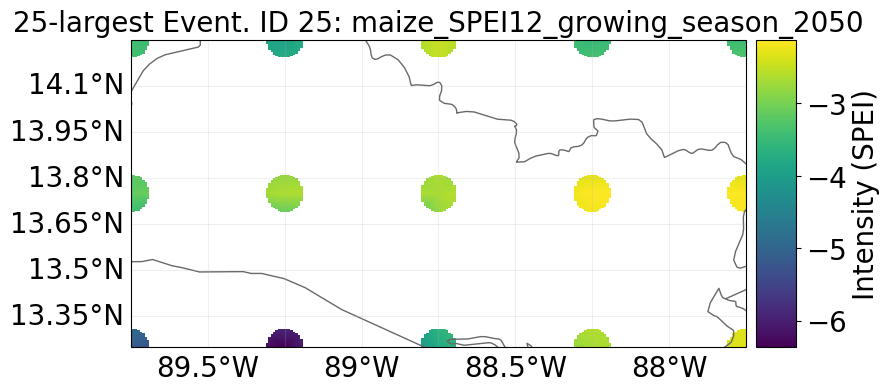

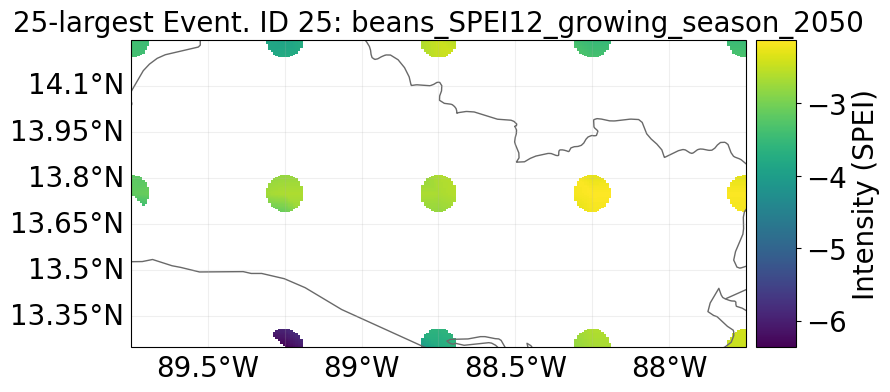

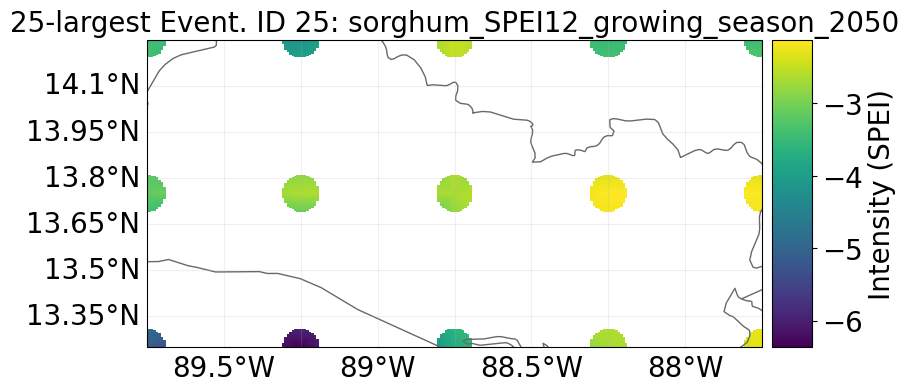

In [34]:
# ============================================================
# CREATE NEW YEARLY HAZARDS
# ============================================================

OUTPUT_DIR = "../../data/hazard/annual/"

for scenario, haz_filename in SPEI12_MONTHLY_FILES.items():
    haz_filepath = Path(SPEI12_DIR) / haz_filename
    print("")
    print("=========================")
    print(f"Scenario: {scenario}")
    print("=========================")

    for crop, growing_season in GROWING_SEASONS.items():
        print(f"\nCrop: {crop}")
        haz = read_hazard_yearly_crop_season(haz_filepath, crop, growing_season)

        print("Hazard shape:", haz.intensity.shape)
        print("First 5 events:", haz.event_name[:5])
        print("Last 5 events:", haz.event_name[-5:])
        print("Intensity min:", haz.intensity.min())
        print("Intensity max:", haz.intensity.max())

        output_filename_stem = f"ElSalvador_SPEI12_{scenario}_{crop}"
        output_filename_hdf5 = output_filename_stem + ".hdf5"
        output_filename_tif = output_filename_stem + ".tif"
        haz.write_hdf5(Path(OUTPUT_DIR) / output_filename_hdf5)
        haz.write_raster(Path(OUTPUT_DIR) / output_filename_tif)

        _ = haz.plot_intensity(event=-haz.size)  # Plot most intense values